# Task 2 - Deep Learning Image Classification

## CIFAR-10 Image Classification using Transfer Learning

### Objective
The objective of this project is to build and evaluate a deep learning image classification model using PyTorch and a pretrained ResNet18 model.

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu
Device: CPU


In [3]:
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset

# Image transformations for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformation for testing
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Use a small subset to keep training manageable
train_dataset = Subset(train_dataset, range(5000))
test_dataset = Subset(test_dataset, range(1000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

100.0%


Training images: 5000
Testing images: 1000


In [4]:
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final layer for CIFAR-10's 10 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Pretrained ResNet18 loaded successfully!")
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Pretrained ResNet18 loaded successfully!
Device: cpu


In [5]:
# Freeze the pretrained ResNet18 layers
for param in model.parameters():
    param.requires_grad = False

# Train only the new final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

print("Pretrained layers frozen.")
print("Final classification layer will be trained.")

Pretrained layers frozen.
Final classification layer will be trained.


In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss function and optimizer are ready.")

Loss function and optimizer are ready.


In [7]:
num_epochs = 3

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch [1/3] Loss: 1.5601 Accuracy: 0.4894
Epoch [2/3] Loss: 1.0360 Accuracy: 0.6780
Epoch [3/3] Loss: 0.8899 Accuracy: 0.7090


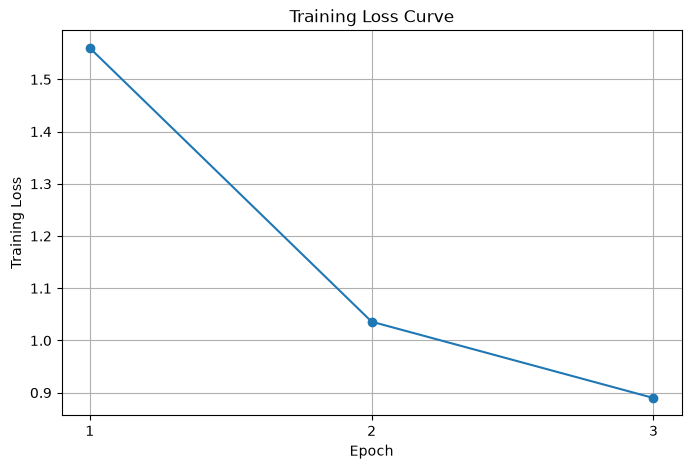

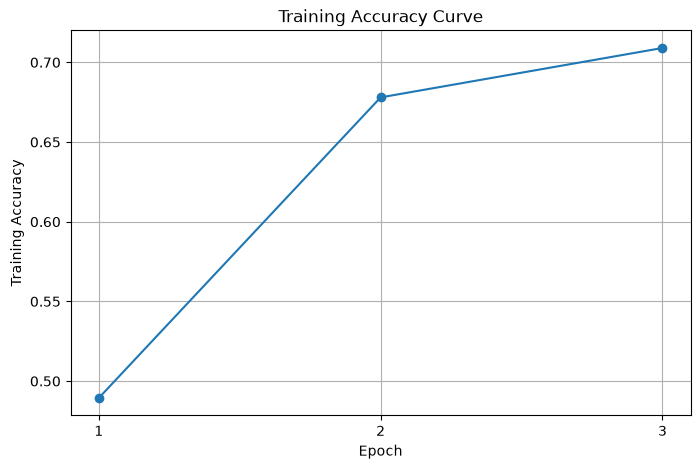

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.xticks(range(1, num_epochs + 1))
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Curve")
plt.xticks(range(1, num_epochs + 1))
plt.grid()
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average="weighted")
recall = recall_score(all_labels, all_predictions, average="weighted")
f1 = f1_score(all_labels, all_predictions, average="weighted")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.7530
Precision: 0.7603
Recall:    0.7530
F1-Score:  0.7503


In [10]:
model_path = "cifar10_resnet18.pth"

torch.save(model.state_dict(), model_path)

print(f"Model saved successfully as: {model_path}")

Model saved successfully as: cifar10_resnet18.pth


## Inference Instructions

The trained model is saved as `cifar10_resnet18.pth`.

To use the saved model for inference:
1. Load the ResNet18 architecture.
2. Replace the final layer with 10 output classes.
3. Load the saved `state_dict`.
4. Apply the same image preprocessing used during testing.
5. Pass the image through the model and select the class with the highest predicted probability.

The model was trained on the CIFAR-10 dataset using transfer learning with a pretrained ResNet18 model.